In [9]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
import math
import torch

from mt_DIDC_config import LABEL2LABEL, PROPERTY_KEY, NEW_LABELS

from tx_GAN_train import CustomDatasetTexturizer

os.environ["CUDA_VISIBLE_DEVICES"] = "1"  

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Selected device: {device}")
print(f'Num available GPUs: ', torch.cuda.device_count())


p = torch.cuda.get_device_properties()
print(f"Device: {p.name} (Memory: {p.total_memory / 1e9:.2f} GB)")

Selected device: cuda
Num available GPUs:  1
Device: NVIDIA TITAN RTX (Memory: 25.19 GB)


## Original dataset

In [11]:
DATA_DIR = "./DIDC_multiclass_coro_v2_prep"
prop_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('props.npy')])
mask_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('mask.npy')])
print(len(prop_files),len(mask_files))

n_pats = min(1, len(prop_files))
pat_idxs = np.random.choice(len(prop_files), size=n_pats, replace=False)
pat_idxs.sort()
print(pat_idxs)

458 458
[270]


load the patients

In [12]:
props_vect = np.load(os.path.join(DATA_DIR, prop_files[pat_idxs[0]]))
mask_vect = np.load(os.path.join(DATA_DIR, mask_files[pat_idxs[0]]))

for idx in pat_idxs[1:]:
    print(f"Loading patient index: {idx}")
    props = np.load(os.path.join(DATA_DIR, prop_files[idx]))
    mask = np.load(os.path.join(DATA_DIR, mask_files[idx]))
    props_vect = np.concatenate([props_vect, props], axis=0) 
    mask_vect = np.concatenate([mask_vect, mask], axis=0)

props_vect.shape, mask_vect.shape


((289, 3, 384, 384), (289, 384, 384))

In [13]:
scales = np.array([200.0, 2000.0, 500.0], dtype=np.float32)

try:
    config_dir = os.path.join(DATA_DIR, 'config_properties.json')
    with open(config_dir, 'r') as f:
        config = json.load(f)
        pd_max = config['PD_max']
        t1_max = config['T1_max']
        t2_max = config['T2_max']

        if config['save_normalized']:
            scales = np.array([pd_max, t1_max, t2_max], dtype=np.float32)[None, :, None, None]
            
except FileNotFoundError:
    print(f"Warning: config_properties.json not found in {DATA_DIR}. Using default scales.")
except KeyError as e:
    print(f"Warning: Missing key {e} in config_properties.json. Using default scales.")

props_vect = props_vect * scales

In [14]:
target_tissues = list(PROPERTY_KEY.keys())
num_tissues = len(target_tissues)

mapping_array = np.zeros(len(NEW_LABELS), dtype=np.int32)

for old_idx, old_label in enumerate(NEW_LABELS):
    mapped_tissue_name = LABEL2LABEL[old_label]
    new_idx = target_tissues.index(mapped_tissue_name)
    mapping_array[old_idx] = new_idx


remapped_mask = mapping_array[mask_vect] 

class_indices = np.arange(num_tissues)[:, None, None, None]  # (15, 1, 1, 1)
vol_mask_onehot = remapped_mask[None, ...] == class_indices
vol_mask_onehot.shape


(15, 289, 384, 384)

In [15]:
props_perm =  np.permute_dims(props_vect, (1, 0, 2, 3))
dist = []
for i in range(vol_mask_onehot.shape[0]):
    class_mask = vol_mask_onehot[i] 
    class_props = props_perm[:, class_mask] 
    dist.append(class_props) 
    print(class_props.shape)


(3, 1456447)
(3, 1348225)
(3, 6440747)
(3, 5726976)
(3, 190555)
(3, 2649393)
(3, 4065827)
(3, 139606)
(3, 214303)
(3, 362566)
(3, 19465)
(3, 891307)
(3, 2280762)
(3, 16683386)
(3, 145219)


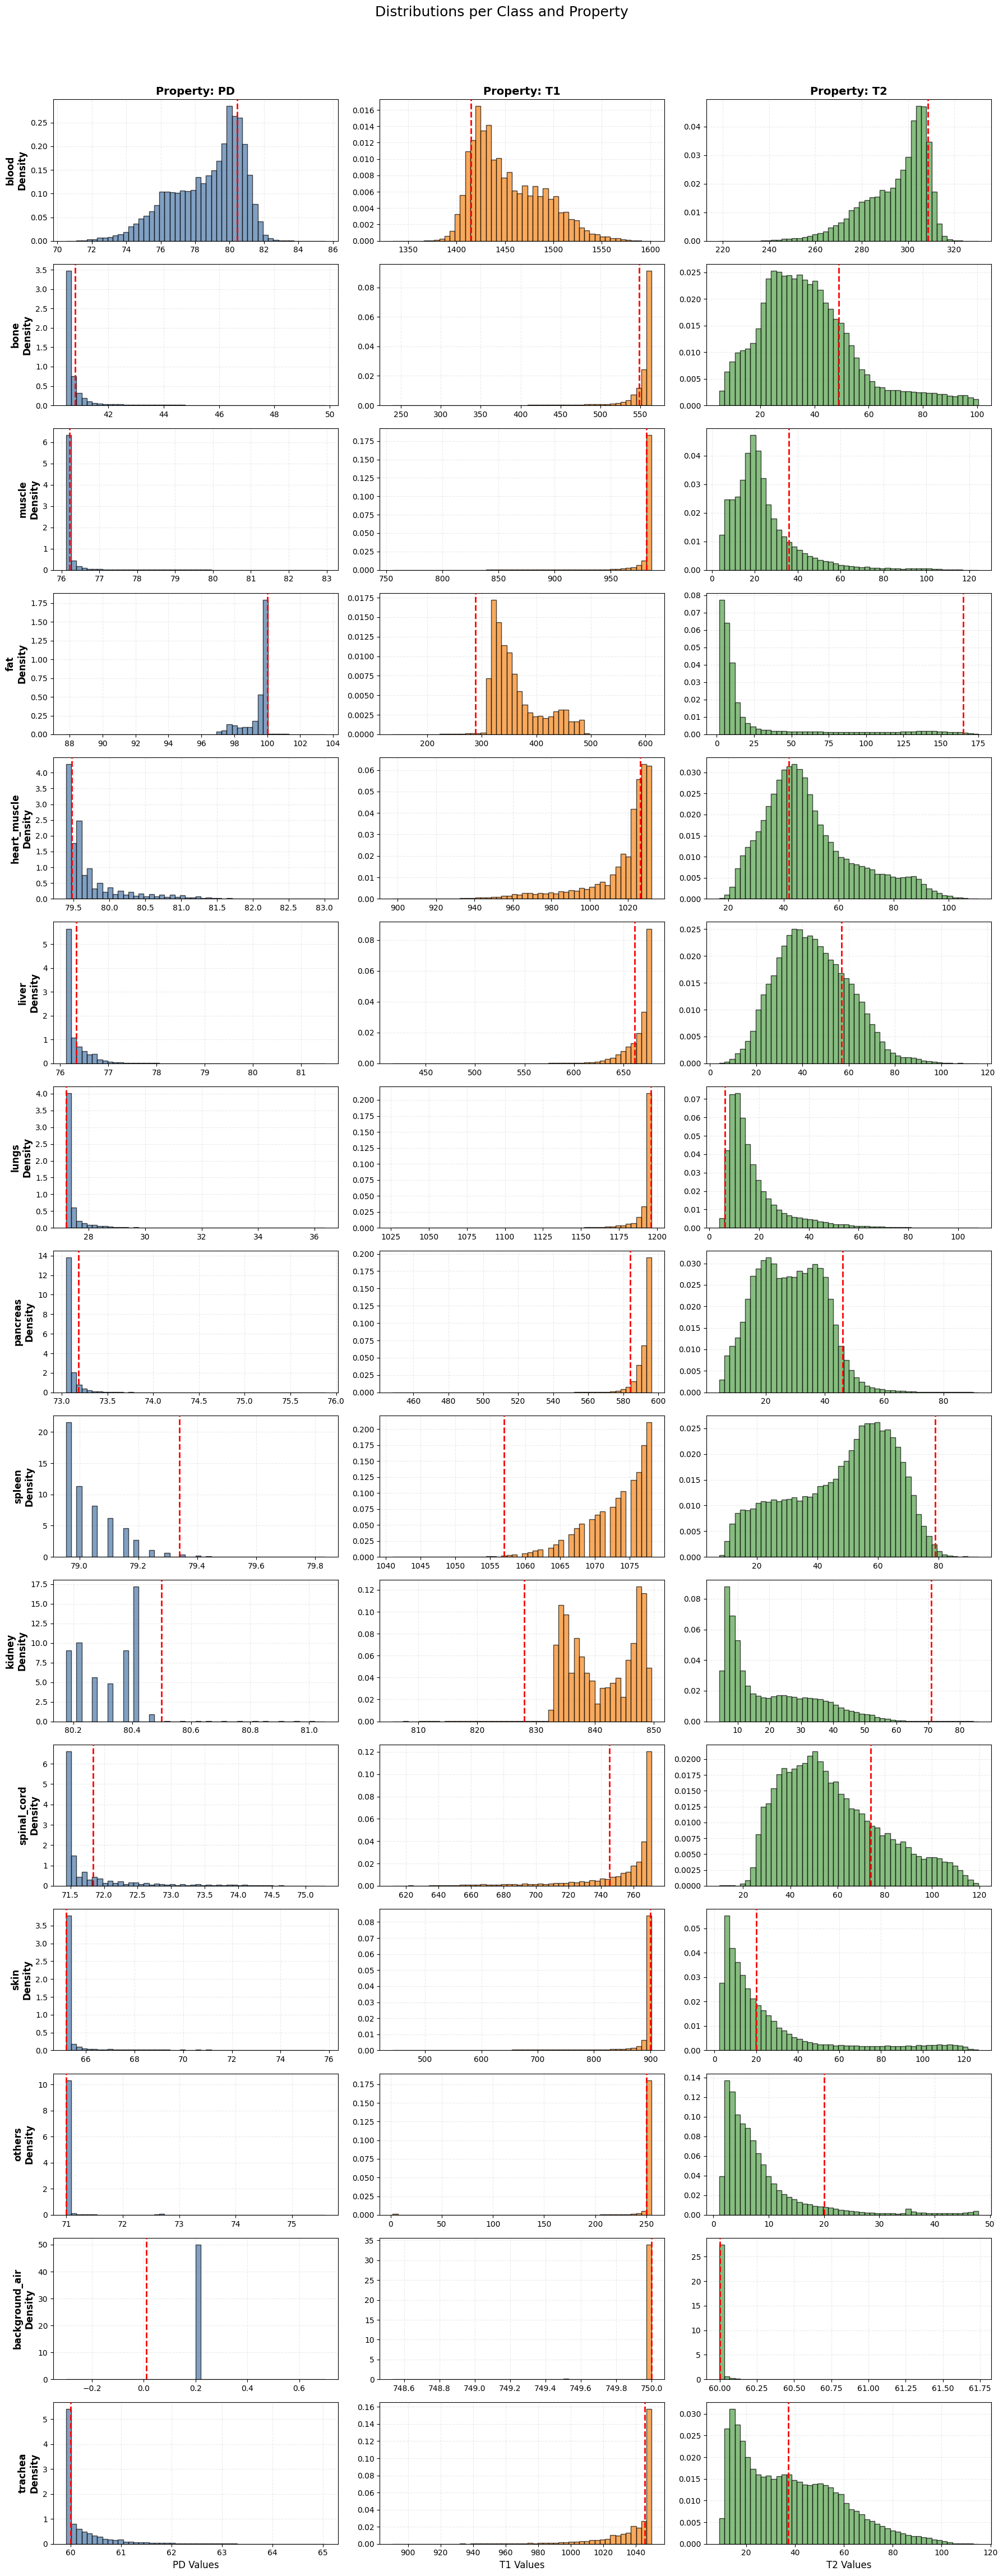

In [16]:
prop_names = ['PD', 'T1', 'T2']
n_classes = len(dist)
n_cols = 3  # PD, T1, T2
n_rows = n_classes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))

default_values = np.array(list(PROPERTY_KEY.values()))


max_points = 100000
colors = ["#4C78A8", "#F58518", "#54A24B"]

for i in range(n_classes):
    class_props = dist[i]
    class_label = list(PROPERTY_KEY.keys())[i]
    
    for j in range(n_cols):
        ax = axes[i, j]
        
        values = class_props[j]
        values = values[np.isfinite(values)]
        
        if values.size > max_points:
            idx = np.random.choice(values.size, size=max_points, replace=False)
            values = values[idx]

        if values.size == 0:
            ax.axvline(x=default_values[i,j], color='red', linestyle='--', linewidth=2, zorder=3)
            ax.set_yticks([])
            continue
        
        ax.hist(values, bins=50, density=True, color=colors[j], alpha=0.7, edgecolor='black', zorder=2)
        
        ax.axvline(x=default_values[i,j], color='red', linestyle='--', linewidth=2, zorder=3)

        ax.grid(alpha=0.25, linestyle="--")
    
        if j == 0:
            ax.set_ylabel(f"{class_label}\nDensity", fontsize=12, fontweight='bold')
            
        if i == 0:
            ax.set_title(f"Property: {prop_names[j]}", fontsize=14, fontweight='bold')
            
        if i == n_rows - 1:
            ax.set_xlabel(f"{prop_names[j]} Values", fontsize=12)

fig.suptitle("Distributions per Class and Property", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()